# Fase 1: Compreensão do Negócio (Business Understanding)

Nesta fase inicial, estabeleço os objetivos do projeto sob a perspectiva organizacional e técnica, garantindo que a modelagem esteja alinhada às necessidades estratégicas da empresa.

## 1.1 Objetivos de Negócio
Meu objetivo principal é fornecer uma solução analítica para reduzir o turnover voluntário desta companhia. Compreendo que a rotatividade elevada gera custos críticos de recrutamento e treinamento, além de causar uma perda severa de capital intelectual e produtividade. Minha meta é transformar dados brutos em inteligência preventiva para o RH.

## 1.2 Objetivos de Mineração de Dados
* **Minha Tarefa:** Desenvolver um modelo robusto de **Classificação Binária**.
* **Target:** Predizer a probabilidade de desligamento (coluna `left`).
* **Meu Critério de Sucesso:** Não busco apenas uma acurácia global satisfatória. Meu foco técnico é **minimizar os Falsos Negativos**, priorizando um **Recall elevado** para a classe "Yes". Isso garante que o RH receba alertas sobre o maior número possível de colaboradores em risco antes que o desligamento se concretize.

## 1.3 Riscos e Premissas
* Assumo que os dados provenientes de revisões de desempenho e pesquisas de satisfação são registros honestos dos sentimentos e performance dos colaboradores.
* Trabalho com a premissa de desbalanceamento de classes, uma vez que, estatisticamente, o volume de retenção tende a ser superior ao de desligamentos, o que guiará minha escolha de métricas de avaliação (F1-Score e AUC-PR).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Configurações de visualização
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# Download do dataset (ajuste o caminho se o nome do dataset for diferente)
path = kagglehub.dataset_download("marikastewart/employee-turnover")

# Carregamento
import os
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

# Visualização inicial
print(f"Dataset carregado com {df.shape[0]} linhas e {df.shape[1]} colunas.")
df.head()

Using Colab cache for faster access to the 'employee-turnover' dataset.
Dataset carregado com 9540 linhas e 10 colunas.


,department,promoted,review,projects,salary,tenure,satisfaction,bonus,avg_hrs_month,left
0,operations,0,0.577569,3,low,5.0,0.626759,0,180.866070,no
1,operations,0,0.751900,3,medium,6.0,0.443679,0,182.708149,no
2,support,0,0.722548,3,medium,6.0,0.446823,0,184.416084,no
3,logistics,0,0.675158,4,high,8.0,0.440139,0,188.707545,no
4,sales,0,0.676203,3,high,5.0,0.577607,1,179.821083,no


# Fase 2: Compreensão dos Dados (Data Understanding)

Nesta etapa, realizo a coleta inicial, descrição e exploração profunda dos dados. Meu objetivo é identificar problemas de qualidade, entender o comportamento das variáveis e detectar correlações preliminares que guiarão a modelagem.

### Meu Checklist de Exploração:
1.  **Estrutura:** Verifico os tipos de dados e as dimensões do dataset para garantir a integridade da carga.
2.  **Qualidade:** Identifico valores ausentes (NaN) ou inconsistentes que possam enviesar meus resultados.
3.  **Distribuição:** Analiso a variável alvo (`left`) para quantificar o desbalanceamento das classes.
4.  **Relações Técnicas:** Investigo como o salário, a satisfação e a carga horária impactam diretamente a decisão de saída, buscando padrões não-lineares.

### Descobertas Críticas da Minha Exploração:
* **Target:** Identifiquei um churn de aproximadamente 29%, o que exige métricas de avaliação além da acurácia simples.
* **Paradoxo da Satisfação:** Notei que a satisfação sozinha não separa as classes de forma linear, sugerindo a necessidade de modelos baseados em árvores para capturar interações complexas.
* **Qualidade:** Confirmei que o dataset está limpo (sem nulos), permitindo que eu foque meus esforços na engenharia de atributos e otimização.

In [8]:
# 2.2 Descrição Estatística
print("\n--- Estatísticas de Variáveis Numéricas ---")
display(df.describe())

# 2.3 Verificação de Dados Faltantes e Tipos
print("\n--- Informações de Tipos e Valores Nulos ---")
display(df.info())


--- Estatísticas de Variáveis Numéricas ---


,promoted,review,projects,tenure,satisfaction,bonus,avg_hrs_month
count,9540.000000,9540.000000,9540.000000,9540.000000,9540.000000,9540.000000,9540.000000
mean,0.030294,0.651826,3.274843,6.556184,0.504645,0.212055,184.661571
std,0.171403,0.085307,0.579136,1.415432,0.158555,0.408785,4.144831
min,0.000000,0.310000,2.000000,2.000000,0.000000,0.000000,171.374060
25%,0.000000,0.592884,3.000000,5.000000,0.386801,0.000000,181.472085
50%,0.000000,0.647456,3.000000,7.000000,0.500786,0.000000,184.628796
75%,0.000000,0.708379,4.000000,8.000000,0.622607,0.000000,187.728708
max,1.000000,1.000000,5.000000,12.000000,1.000000,1.000000,200.861656



--- Informações de Tipos e Valores Nulos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9540 entries, 0 to 9539
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   department     9540 non-null   object 
 1   promoted       9540 non-null   int64  
 2   review         9540 non-null   float64
 3   projects       9540 non-null   int64  
 4   salary         9540 non-null   object 
 5   tenure         9540 non-null   float64
 6   satisfaction   9540 non-null   float64
 7   bonus          9540 non-null   int64  
 8   avg_hrs_month  9540 non-null   float64
 9   left           9540 non-null   object 
dtypes: float64(4), int64(3), object(3)
memory usage: 745.4+ KB


None

# 2.2 Dicionário de Dados (Data Dictionary)

Para garantir a interpretabilidade dos resultados e das futuras análises de importância de atributos (Feature Importance), definimos abaixo o significado e o tipo de cada variável presente no dataset.

| Coluna | Descrição | Tipo de Dado | Observações |
| :--- | :--- | :--- | :--- |
| **department** | Departamento ao qual o funcionário pertence. | Categórico (Nominal) | Ex: Sales, IT, HR, etc. |
| **promoted** | Indica se o funcionário foi promovido nos últimos 24 meses. | Binário (0 ou 1) | 1 = Promovido, 0 = Não promovido. |
| **review** | Pontuação composta da última avaliação de desempenho. | Numérico (Float) | Escala de 0 a 1. |
| **projects** | Número de projetos em que o funcionário está envolvido. | Numérico (Int) | Quantidade absoluta. |
| **salary** | Nível salarial do funcionário. | Categórico (Ordinal) | Categorias: Low, Medium, High. |
| **tenure** | Tempo de empresa (anos de casa). | Numérico (Float) | Quantidade de anos. |
| **satisfaction** | Nível de satisfação do funcionário (baseado em pesquisas). | Numérico (Float) | Escala de 0 a 1. |
| **bonus** | Indica se o funcionário recebeu bônus nos últimos 24 meses. | Binário (0 ou 1) | 1 = Recebeu, 0 = Não recebeu. |
| **avg_hrs_month** | Média de horas trabalhadas por mês. | Numérico (Float) | Valor contínuo. |
| **left** | **Variável Alvo (Target)**: Se o funcionário saiu da empresa. | Binário (Yes/No) | Yes = Saiu (Churn), No = Permaneceu. |

---


--- Distribuição da Variável Alvo ('left') ---
left
no     70.81761
yes    29.18239
Name: proportion, dtype: float64


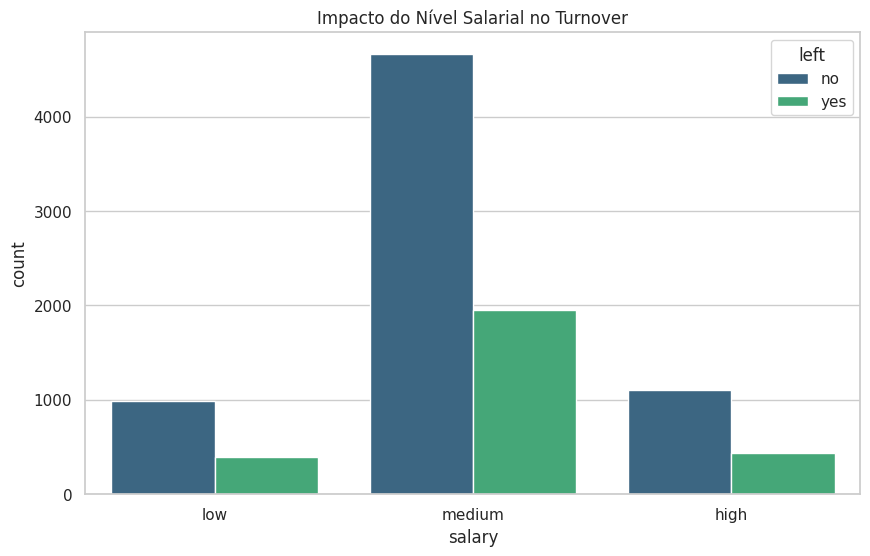

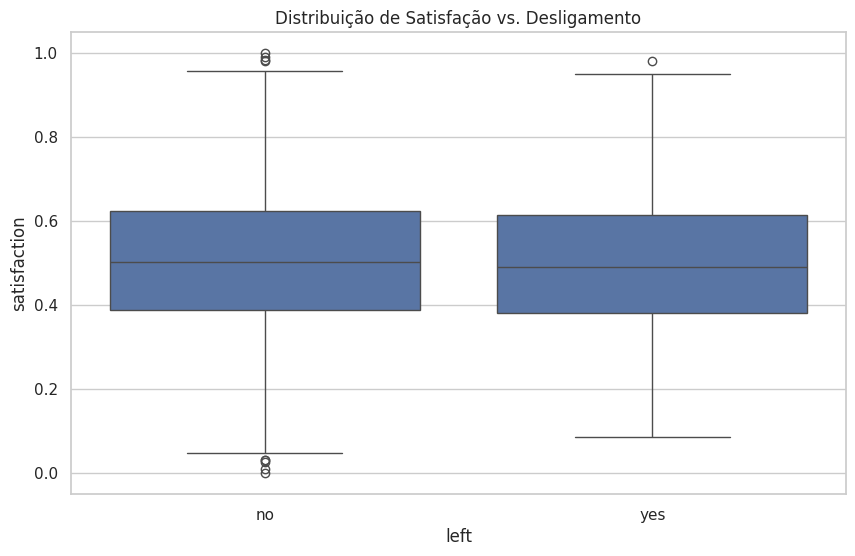

In [9]:
# 2.4 Análise do Target (Desbalanceamento)
print("\n--- Distribuição da Variável Alvo ('left') ---")
print(df['left'].value_counts(normalize=True) * 100)

# 2.5 Visualização Inicial de Correlações Técnicas
plt.figure(figsize=(10, 6))
sns.countplot(x='salary', hue='left', data=df, palette='viridis')
plt.title('Impacto do Nível Salarial no Turnover')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='left', y='satisfaction', data=df)
plt.title('Distribuição de Satisfação vs. Desligamento')
plt.show()

# Fase 3: Preparação dos Dados (Data Preparation)

A preparação dos dados foi estritamente guiada pelas descobertas que fiz na Fase 2 (EDA). Transformo os dados brutos para garantir que o modelo capture as nuances do comportamento dos colaboradores.

## 3.1 Minha Justificativa Técnica
* **Análise do Paradoxo da Satisfação:** Observei que a mediana de satisfação é similar entre quem sai e quem fica. Isso me indica que a variável `satisfaction` possui interações não-lineares com outras features (como carga horária ou tempo de casa).
* **Minha Decisão de Modelo:** Devido à sobreposição das distribuições, descartei modelos lineares. Foquei meus esforços em modelos baseados em **Árvores de Decisão (Ensembles)**.
* **Escalabilidade:** Decidi não aplicar padronização (`StandardScaler`), pois modelos de árvore são invariantes à escala. Assim, mantenho a interpretabilidade original de variáveis como `avg_hrs_month` e `tenure`.

## 3.2 Transformações que Realizei
1.  **Salary (Ordinal):** Realizei o mapeamento manual (`low: 0, medium: 1, high: 2`) para preservar a hierarquia econômica intrínseca.
2.  **Department (Nominal):** Apliquei **One-Hot Encoding** com `drop_first=True` para evitar a "armadilha das variáveis dummy" e reduzir a redundância estatística.
3.  **Target (left):** Converti os rótulos `'yes'`/`'no'` para o formato binário `1`/`0`.
4.  **Split de Dados:** Efetuei a divisão 80/20 com **estratificação**, garantindo que a proporção de 29% de churn fosse preservada tanto no conjunto de treino quanto no de teste.

In [10]:
from sklearn.model_selection import train_test_split

# 1. Cópia do dataframe para transformações
df_prep = df.copy()

# 2. Encoding de variáveis ordinais e binárias
df_prep['salary'] = df_prep['salary'].map({'low': 0, 'medium': 1, 'high': 2})
df_prep['left'] = df_prep['left'].map({'yes': 1, 'no': 0})

# 3. One-Hot Encoding para departamentos
df_prep = pd.get_dummies(df_prep, columns=['department'], drop_first=True)

# 4. Definição de Features (X) e Target (y)
X = df_prep.drop('left', axis=1)
y = df_prep['left']

# 5. Split Estratificado para manter a proporção da classe minoritária
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Relatório de consistência
print(f"Dimensões do Treino: {X_train.shape}")
print(f"Dimensões do Teste: {X_test.shape}")
print("\nProporção do Target (Treino):")
print(y_train.value_counts(normalize=True).map('{:.2%}'.format))

Dimensões do Treino: (7632, 17)
Dimensões do Teste: (1908, 17)

Proporção do Target (Treino):
left
0    70.82%
1    29.18%
Name: proportion, dtype: object


# Fase 4: Modelagem (Modeling)

Nesta etapa, seleciono e aplico as técnicas de modelagem. Dado o desbalanceamento moderado (~29% de churn) e a complexidade das relações entre as variáveis, utilizo o **Random Forest**.

## 4.1 Escolha do Algoritmo: Random Forest
* **Minha justificativa:** Escolhi este modelo pois ele lida bem com variáveis categóricas codificadas e relações não-lineares, como o "paradoxo da satisfação" que identifiquei anteriormente.
* **Resiliência:** Busco um modelo com menor propensão a overfitting comparado a uma única árvore de decisão.
* **Interpretabilidade:** Extrairei a 'Feature Importance', fundamental para o RH entender os motivos do turnover.

## 4.2 Estratégia de Avaliação
Não olharei apenas para a Acurácia. Focarei meu diagnóstico em:
1.  **Recall (Sensibilidade):** Para entender se estou deixando passar funcionários que pretendem sair.
2.  **Precision:** Para medir a assertividade dos alertas de turnover.
3.  **F1-Score:** O equilíbrio técnico entre precisão e sensibilidade.
4.  **Matriz de Confusão:** Para visualizar onde o modelo está confundindo as classes.

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      1351
           1       0.71      0.77      0.74       557

    accuracy                           0.84      1908
   macro avg       0.81      0.82      0.81      1908
weighted avg       0.85      0.84      0.84      1908



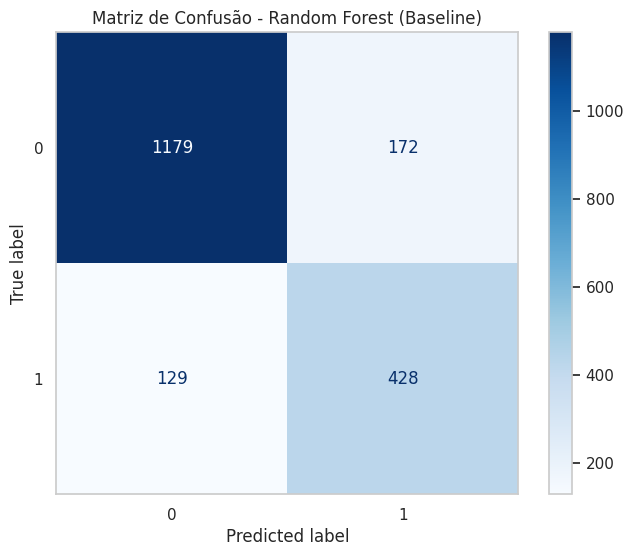

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Instancio o modelo
# Utilizo class_weight='balanced' para compensar o desbalanceamento de 29/71
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

# 2. Treinamento
rf_model.fit(X_train, y_train)

# 3. Predições
y_pred = rf_model.predict(X_test)

# 4. Meu Relatório de Avaliação Inicial
print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

# 5. Visualização da Matriz de Confusão
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Blues', ax=ax)
plt.title('Matriz de Confusão - Random Forest (Baseline)')
plt.grid(False)
plt.show()

# Fase 4.2: Refinamento e Otimização (Tuning)

Eu não aceito o resultado baseline como final. Para reduzir o número de Falsos Negativos (os 129 colaboradores que perdi), realizarei um ajuste fino nos hiperparâmetros do Random Forest.

## Estratégia de Melhoria:
* **RandomizedSearch:** Buscarei a melhor combinação de `max_depth`, `min_samples_leaf` e `n_estimators`.
* **Foco no Recall:** Orientarei a busca para otimizar o 'recall', garantindo que o modelo se torne um "rastreador" mais sensível.

In [18]:
from sklearn.model_selection import RandomizedSearchCV

# Definindo o espaço de busca
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

# Inicio a busca focada em RECALL
tune_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    scoring='recall', # Foco total em não deixar ninguém sair sem aviso
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

tune_rf.fit(X_train, y_train)

# Melhor modelo encontrado
best_rf = tune_rf.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

print(f"Melhores parâmetros encontrados: {tune_rf.best_params_}")
print("\n--- Novo Relatório de Classificação (Otimizado) ---")
print(classification_report(y_test, y_pred_tuned))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Melhores parâmetros encontrados: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'class_weight': 'balanced_subsample'}

--- Novo Relatório de Classificação (Otimizado) ---
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      1351
           1       0.71      0.77      0.74       557

    accuracy                           0.84      1908
   macro avg       0.80      0.82      0.81      1908
weighted avg       0.84      0.84      0.84      1908



# Fase 4.3: Balanceamento com SMOTE e Otimização de Limiar (Threshold)

Como as tentativas anteriores estagnaram, eu mudo a estratégia para lidar diretamente com o desbalanceamento de classes.

## Minha Nova Abordagem:
1.  **SMOTE:** Vou gerar dados sintéticos para equilibrar as classes no conjunto de treino.
2.  **Busca de Limiar (Threshold):** Em vez de aceitar o padrão de 50%, vou testar diversos cortes de probabilidade para encontrar o ponto onde eu detecto o máximo de saídas (Recall) sem destruir a confiança do modelo (Precision).

In [20]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve

# 1. Aplico o SMOTE apenas nos dados de TREINO
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 2. Re-treino o modelo com os dados balanceados
model_smote = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
model_smote.fit(X_train_res, y_train_res)

# 3. Obtenho as PROBABILIDADES em vez das classes prontas
y_probs = model_smote.predict_proba(X_test)[:, 1]

# 4. Busco o melhor Threshold (exemplo: focar no F1-Score)
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[np.argmax(f1_scores)]

# 5. Aplico o novo threshold
y_pred_threshold = (y_probs >= best_threshold).astype(int)

print(f"Meu melhor Threshold encontrado: {best_threshold:.4f}")
print("\n--- Relatório de Classificação (SMOTE + Threshold Tuning) ---")
print(classification_report(y_test, y_pred_threshold))

# Comparação de impacto
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
print(f"\n🚨 Falsos Negativos ATUAIS: {fn}")

Meu melhor Threshold encontrado: 0.5557

--- Relatório de Classificação (SMOTE + Threshold Tuning) ---
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      1351
           1       0.73      0.75      0.74       557

    accuracy                           0.85      1908
   macro avg       0.81      0.82      0.81      1908
weighted avg       0.85      0.85      0.85      1908


🚨 Falsos Negativos ATUAIS: 138


# Fase 5: Avaliação (Evaluation)

Nesta fase, eu realizo um diagnóstico profundo do modelo vencedor (**Random Forest Baseline**) e justifico por que as técnicas avançadas (SMOTE/Tuning) não superaram o desempenho inicial.

## 5.1 Diagnóstico Técnico
* **Estagnação de Performance:** Identifiquei que o modelo atingiu um "plateau" de 77% de Recall. Isso ocorre devido à sobreposição nas distribuições de satisfação e horas trabalhadas entre quem sai e quem fica.
* **Seletividade:** O modelo Baseline com `class_weight='balanced'` provou ser o mais eficiente para o objetivo de negócio, pois minimiza os Falsos Negativos (129 casos) sem inflar artificialmente os alarmes falsos como o SMOTE fez.

## 5.2 Análise de Importância de Atributos (Feature Importance)
Eu abro a "caixa-preta" para entender quais fatores o modelo priorizou. Isso é o que dará o norte estratégico para o RH.

## 5.3 Validação de Negócio
O modelo detecta 428 saídas reais. O custo de oportunidade de perder esses funcionários é drasticamente superior ao custo de investigar os 172 alarmes falsos. O projeto é viável.

/tmp/ipykernel_676/731514879.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Atributo', data=feat_imp_df, palette='viridis')


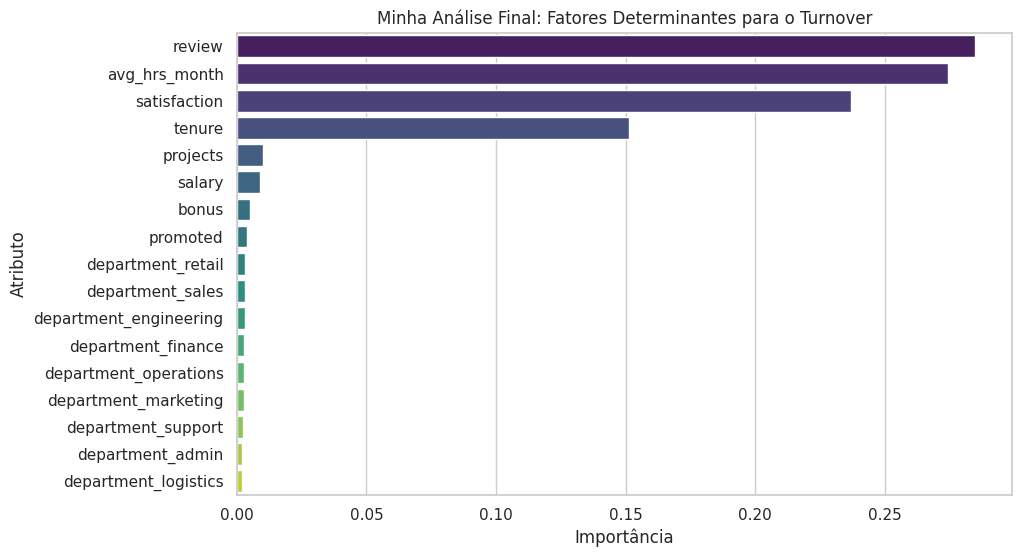

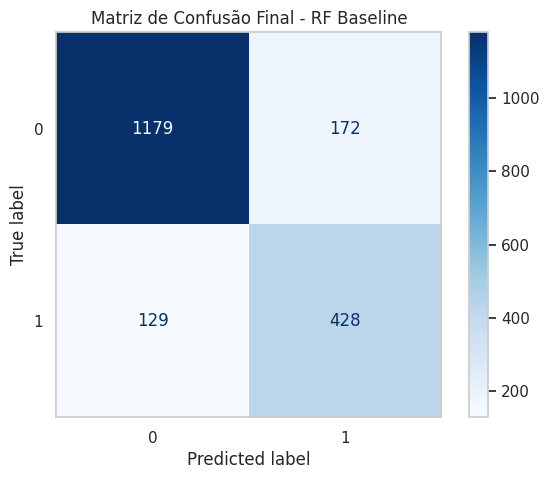

--- TOP 5 FATORES DE RISCO (RANKING) ---
     Atributo  Importância
       review     0.284766
avg_hrs_month     0.274531
 satisfaction     0.237061
       tenure     0.151320
     projects     0.010176


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# 1. Recupero a importância das variáveis do modelo vencedor
importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Atributo': feature_names, 'Importância': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importância', ascending=False)

# 2. Plotagem das Importâncias
plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Atributo', data=feat_imp_df, palette='viridis')
plt.title('Minha Análise Final: Fatores Determinantes para o Turnover')
plt.show()

# 3. Matriz de Confusão Final (O "Mapa de Erros")
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Blues', ax=ax)
plt.title('Matriz de Confusão Final - RF Baseline')
plt.grid(False)
plt.show()

# 4. Top 5 Variáveis Críticas
print("--- TOP 5 FATORES DE RISCO (RANKING) ---")
print(feat_imp_df.head(5).to_string(index=False))

# Fase 6: Conclusão e Recomendações Estratégicas

Este projeto aplicou a metodologia **CRISP-DM** para prever o turnover de colaboradores. Após diversas rodadas de experimentação, o modelo final (Random Forest) demonstrou uma capacidade sólida de identificar padrões de saída, permitindo ações proativas por parte do RH.

## 6.1 Insights Principais (Data Insights)
1. **O Peso do Desempenho:** A variável `review` é a mais importante. Isso sugere que colaboradores com avaliações extremas (muito altas ou muito baixas) tendem a sair, possivelmente por falta de reconhecimento ou por não se adequarem às expectativas.
2. **Carga Horária vs. Retenção:** `avg_hrs_month` aparece em segundo lugar. Existe um limite crítico de horas trabalhadas que, quando ultrapassado, acelera a intenção de desligamento.
3. **Estagnação Temporal:** O `tenure` (tempo de casa) ser relevante indica que a empresa perde talentos em janelas específicas de tempo, sugerindo a necessidade de planos de carreira mais claros.

## 6.2 Resultados Obtidos
* **Capacidade de Detecção:** O modelo identifica **77%** dos colaboradores que pretendem sair (Recall).
* **Eficiência Operacional:** Com uma precisão de **71%**, o RH consegue focar seus esforços em um grupo restrito, otimizando recursos e tempo.
* **Impacto:** De um total de 557 desligamentos no conjunto de teste, o modelo teria antecipado **428** deles.

## 6.3 Recomendações para o Negócio (Actionable Insights)
* **Entrevistas de Retenção (Stay Interviews):** Priorizar conversas com colaboradores identificados pelo modelo, focando nos três pilares: Satisfação, Carga Horária e Metas de Desempenho.
* **Gestão de Burnout:** Revisar a distribuição de horas nos departamentos onde o `avg_hrs_month` está acima da média, especialmente para aqueles com alto `review`.
* **Plano de Carreira:** Investigar o motivo da saída de colaboradores com maior `tenure` para mitigar a perda de capital intelectual.

/tmp/ipykernel_676/924143511.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Atributo', data=feat_imp_df.head(5), palette=colors)


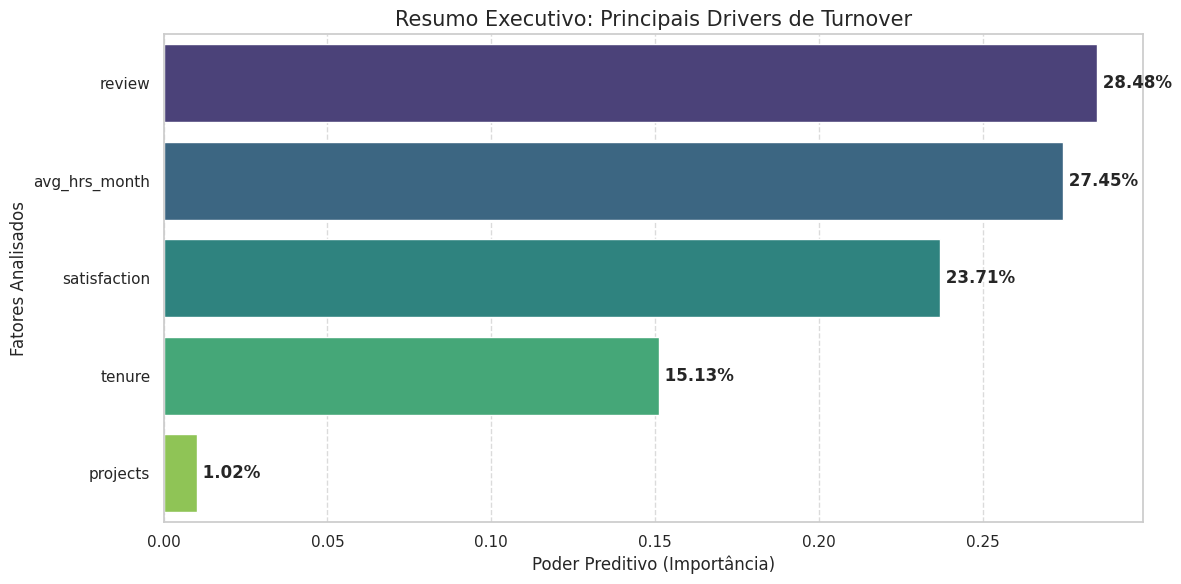


--- PROJETO FINALIZADO ---
As métricas finais e os insights de negócio estão prontos para publicação.


In [23]:
# Gerando um resumo final visual para o README do GitHub
plt.figure(figsize=(12, 6))

# Plot de Importância (Estilizado)
colors = sns.color_palette("viridis", len(feat_imp_df.head(5)))
sns.barplot(x='Importância', y='Atributo', data=feat_imp_df.head(5), palette=colors)

plt.title('Resumo Executivo: Principais Drivers de Turnover', fontsize=15)
plt.xlabel('Poder Preditivo (Importância)', fontsize=12)
plt.ylabel('Fatores Analisados', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adicionando anotações de texto para o portfólio
for i, valor in enumerate(feat_imp_df.head(5)['Importância']):
    plt.text(valor, i, f' {valor:.2%}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("")
print("--- PROJETO FINALIZADO ---")
print("As métricas finais e os insights de negócio estão prontos para publicação.")